# Resampling Köppen–Geiger Climate Classification to 25 km

The Köppen–Geiger (KG) climate classification was resampled to a 25 km grid to match the spatial resolution of the TB\_diff dataset.

This preprocessing step supports the *Section 3.3: Clustering of TB\_diff Climatology*, where the dominant climate regimes associated with each cluster are examined. The goal is not to perform a strict quantitative analysis, but rather to provide a first-order characterization of the climate types represented within each cluster.

The original dataset is derived from:

> *KGClim historical: A 1-km global dataset of historical (1979–2013) Köppen–Geiger climate classification and bioclimatic variables*

Among the available versions, we used **`KGClim_V1_historical_1984_2013`**, as it is similar to the study period (1988–2022).

The 1 km resolution categorical data were resampled to 25 km using a mode aggregation, preserving the dominant climate class within each grid cell.

In [1]:
import sys
import os
import platform
import importlib
import math
import glob
from tqdm import tqdm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import multiprocessing as mp
import calendar
import netCDF4 as nc
import xarray as xr
from datetime import timedelta
import datetime
from dateutil.relativedelta import relativedelta
from scipy.interpolate import griddata
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pyproj import Proj, transform
import matplotlib.colors as colors
import matplotlib.path as mpath
import rioxarray
import rasterio
from mpl_toolkits.axes_grid1 import make_axes_locatable
import subprocess
from IPython.display import display, Markdown


if platform.system() == 'Darwin':  # macOS
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
else:
    base_FP = '/home/nayoung/data'
    cpuserver_data_FP = '/home/nayoung/cpuserver_data'
    nas_data_FP = '/home/nayoung/nas_data'
    data2_FP = '/home/nayoung/data2'
sys.path.append(base_FP + '/python_modules')

# HydroAI libs
import HydroAI.Data as hData
import HydroAI.Plot as hPlot
import HydroAI.Grid as hGrid
import HydroAI.Land_Properties as hLP
importlib.reload(hData);
importlib.reload(hPlot);
importlib.reload(hGrid);
importlib.reload(hLP);

# Ignore runtime warnings
import warnings
warnings.filterwarnings("ignore")


## Create a function to plot the North Polar region, as the study focuses on areas north of 60°N

In [2]:
def plot_Northpole(domain_lon, domain_lat, data, label_title, cmap,
                   vmin=-1, vmax=1, vcenter=0, bounds=None, ticks=None, ticklabels=None):

    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection=ccrs.NorthPolarStereo(central_longitude=0))

    theta = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

    ax.set_extent([-180, 180, 60, 90], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.OCEAN, facecolor='powderblue', zorder=0)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=1)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5, zorder=3)

    masked_data = np.ma.masked_invalid(data)

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(alpha=0)

    # Continuous/Discrete norm
    if bounds is None:
        if vcenter is None:
            norm = colors.Normalize(vmin=vmin, vmax=vmax)
        else:
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    else:
        norm = colors.BoundaryNorm(bounds, ncolors=cmap_obj.N, clip=True)

    mesh = ax.pcolormesh(
        domain_lon, domain_lat, masked_data,
        transform=ccrs.PlateCarree(),
        cmap=cmap_obj,
        norm=norm,
        zorder=2,
        shading="auto"
    )

    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                      linewidth=1, color='gray', alpha=0.5, linestyle='--', zorder=4)
                
    gl.xlabel_style = {'size': 18}
    gl.ylabel_style = {'size': 18}

    gl.top_labels = False
    gl.right_labels = False

    cbar = plt.colorbar(
        mesh, ax=ax, orientation='horizontal',
        pad=0.07, shrink=0.8, extend='neither',
        boundaries=bounds if bounds is not None else None,
        ticks=ticks
    )
    cbar.set_label(label_title, fontsize=12, labelpad=10)
    cbar.ax.tick_params(labelsize=18)

    if ticklabels is not None:
        cbar.set_ticklabels(ticklabels)
    elif bounds is None:
        tick_values = np.linspace(vmin, vmax, 5)
        cbar.set_ticks(tick_values)
        cbar.set_ticklabels([f'{v:.2f}' for v in tick_values])

    plt.title(label_title, fontsize=16, pad=20)
    plt.show()

    return fig, ax

## Converting GeoTIFF to NetCDF

The original 1 km Köppen–Geiger climate classification data were provided in GeoTIFF (`.tif`) format.  
To facilitate efficient processing and integration with other datasets, the files were converted to NetCDF (`.nc`) format.
The conversion was performed using the `gdal_translate` utility from the GDAL library.

In [3]:
tif_path = f"{cpuserver_data_FP}/personal_data/project_snow/KC_classification/kc_1984_2013.tif"
nc_path  = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/kc_1984_2013_25km_north60.nc"

subprocess.run([
    "gdal_translate",
    "-of", "NetCDF",
    "-co", "FORMAT=NC4",
    tif_path,
    nc_path
], check=True)


Warning 1: PROJ: proj_create_from_database: Open of /home/nayoung/miniconda3/envs/hydroAI/share/proj failed


Input file size is 43200, 18000
0...10...20...30...40...50...60...70...80...90...100 - done in 00:00:13.


CompletedProcess(args=['gdal_translate', '-of', 'NetCDF', '-co', 'FORMAT=NC4', '/home/nayoung/cpuserver_data/personal_data/project_snow/KC_classification/kc_1984_2013.tif', '/home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/kc_1984_2013_25km_north60.nc'], returncode=0)

## Verifying and Resampling the NetCDF File

The generated NetCDF file was first inspected to ensure that the variables, dimensions, and metadata were correctly preserved during the conversion process. After verification, the data were resampled to a 25 km grid to match the spatial resolution of the TB\_diff dataset.

In [4]:
with nc.Dataset(nc_path) as ds:
    lon = ds.variables['lon'][:]
    lat = ds.variables['lat'][:]
    Band1 = ds.variables['Band1'][:]

print(np.unique(Band1))
print(lon[0], lon[-1]) # -179.99, 179.99
print(lat[0], lat[-1]) # -59.99, 89.99

# The latitude is ordered from -60 to 90, so it is flipped (upside down) to match the desired descending order (north to south).
lat_desc = lat[::-1]
Band1_desc = Band1[::-1, :]

lon_2d, lat_2d = np.meshgrid(lon, lat_desc)

# Resample to 0.25
lon_25, lat_25 = hGrid.generate_lon_lat_eqdgrid(0.25)
lat_25_idx = lat_25[:, 0] >= -60
lat_25 = lat_25[lat_25_idx]
lon_25 = lon_25[lat_25_idx]

# Before resampling, exclude the fillvalue of -3.4E38
if np.ma.isMaskedArray(Band1_desc):
    Band1_desc = Band1_desc.filled(np.nan)

KC_map = hData.Resampling(lon_25, lat_25, lon_2d, lat_2d, Band1_desc, 'nearest', 'mode', mag_factor=2)
print(np.unique(KC_map))
print(np.shape(KC_map))


[110.0 120.0 130.0 211.0 212.0 221.0 222.0 311.0 312.0 313.0 321.0 322.0
 323.0 331.0 332.0 333.0 411.0 412.0 413.0 421.0 422.0 423.0 424.0 431.0
 432.0 433.0 434.0 510.0 520.0 --]
-179.99583333333334 179.99583333333334
-59.99583333333333 89.99583333333334
[110. 120. 130. 211. 212. 221. 222. 311. 312. 313. 321. 322. 323. 331.
 332. 333. 411. 412. 413. 421. 422. 423. 424. 431. 432. 433. 434. 510.
 520.  nan]
(600, 1440)


## Crop to Regions North of 60°N and Plot the Final Output

The resampled dataset was cropped to include only regions north of 60°N, consistent with the spatial domain of this study. The final processed data were then visualized to confirm that the spatial coverage and climate classification patterns were preserved after cropping and resampling.

(120, 1440)
[212. 332. 333. 412. 413. 423. 424. 432. 433. 434. 510. 520.  nan]


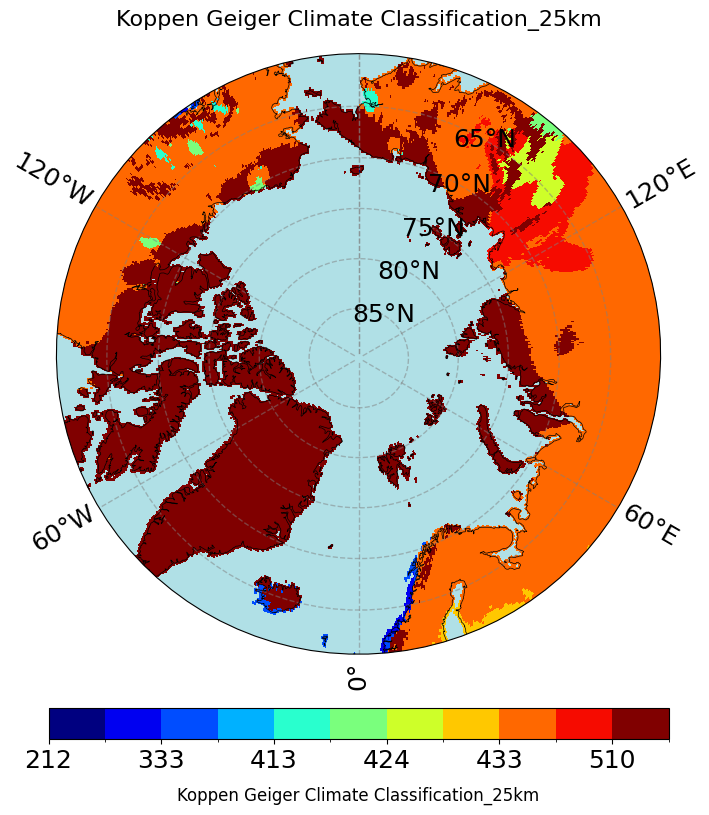

(<Figure size 1000x1000 with 2 Axes>,
 <GeoAxes: title={'center': 'Koppen Geiger Climate Classification_25km'}>)

In [5]:
# Cut the map to the lat>=60
lat_idx = lat_25[:, 0] >= 60
lon_60N, lat_60N = lon_25[lat_idx], lat_25[lat_idx]
Band1_60N = KC_map[lat_idx]

print(np.shape(Band1_60N))
print(np.unique(Band1_60N))

# Plot
plot_Northpole(lon_60N, lat_60N, Band1_60N, 'Koppen Geiger Climate Classification_25km', 'jet', bounds = [212, 332, 333, 412, 413, 423, 424, 432, 433, 434, 510, 520])

## Save

In [6]:
out_nc = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/kc_1984_2013_25km_north60.nc"

with nc.Dataset(out_nc, "w") as ds:
    ds.createDimension("lat", lat_60N.shape[0])
    ds.createDimension("lon", lon_60N.shape[1])

    lat_var = ds.createVariable("lat", "f4", ("lat",))
    lon_var = ds.createVariable("lon", "f4", ("lon",))
    kg_var  = ds.createVariable(
        "koppen_geiger", "i2", ("lat", "lon"),
        fill_value=-9999
    )

    lat_var[:] = lat_60N[:, 0]
    lon_var[:] = lon_60N[0, :]
    kg_var[:]  = Band1_60N.astype("int16")

    kg_var.long_name = "Koppen-Geiger climate classification"
    kg_var.description = "Resampled to 0.25 degree grid using nearest + mode"
    kg_var.source = "Koppen-Geiger (1984–2013)"

print("Saved to:", out_nc)


Saved to: /home/nayoung/cpuserver_data/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/kc_1984_2013_25km_north60.nc


## Cluster-wise Dominant Climate Classification Analysis

Using the resampled Köppen–Geiger climate classification map, we analyzed the distribution of climate types within each cluster.
For each cluster, summary statistics were computed to identify the dominant climate classification, providing a first-order characterization of the environmental conditions associated with each cluster.
The figure below is excerpted from the dataset’s `README.txt`.


<img src="../Git_figures/KC_climate_classes.png" width="700">

In [7]:
# Load the TB_cluster_map and KC_map
TB_cluster_map_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/Clusters/TB_cluster_map.nc"
KC_map_path = f"{cpuserver_data_FP}/python_modules/Nayoung/Results_to_ensure_reproducibility/LULC/kc_1984_2013_25km_north60.nc"

# Open the NetCDF files
with nc.Dataset(TB_cluster_map_path) as ds:
    TB_cluster_map = ds.variables["TB_cluster"][:]  

with nc.Dataset(KC_map_path) as ds:
    KC_map = ds.variables["koppen_geiger"][:]        

# Convert the data to float64 and fill the fillvalue with NaN
if np.ma.isMaskedArray(TB_cluster_map):
    TB_cluster_map = TB_cluster_map.astype("float64").filled(np.nan)
else:
    TB_cluster_map = TB_cluster_map.astype("float64")

if np.ma.isMaskedArray(KC_map):
    KC_map = KC_map.astype("float64").filled(np.nan)
else:
    KC_map = KC_map.astype("float64")

KC_map[KC_map < -1e30] = np.nan



In [13]:
# Plot the table that shows the count and fraction of each cluster and climate class
valid = np.isfinite(TB_cluster_map) & np.isfinite(KC_map)

cl = TB_cluster_map[valid].astype(int)
kc = KC_map[valid].astype(int)

df = pd.DataFrame({"cluster": cl, "koppen": kc})

tab_count = pd.crosstab(df["cluster"], df["koppen"])
tab_frac  = tab_count.div(tab_count.sum(axis=1), axis=0)


# Plot the Count table
display(Markdown("### Count Table"))

styled_count = (
    tab_count
    .style
    .set_properties(**{"text-align": "center"})
)

display(styled_count)

# Plot the Fraction table
display(Markdown("### Fraction Table"))

styled_frac = (
    tab_frac
    .style
    .format("{:.3f}") 
    .set_properties(**{"text-align": "center"})
)

display(styled_frac)


### Count Table

koppen,332,333,413,423,424,432,433,434,510,520
cluster,,,,,,,,,,
0,0,1,87,47,15,174,11467,391,1816,290
1,0,0,52,25,7,0,4936,171,6778,6
2,0,0,4,146,721,0,7990,2414,2573,0
3,27,60,24,23,0,176,1908,57,3467,13


### Fraction Table

koppen,332,333,413,423,424,432,433,434,510,520
cluster,,,,,,,,,,
0,0.000,0.000,0.006,0.003,0.001,0.012,0.803,0.027,0.127,0.020
1,0.000,0.000,0.004,0.002,0.001,0.000,0.412,0.014,0.566,0.001
2,0.000,0.000,0.000,0.011,0.052,0.000,0.577,0.174,0.186,0.000
3,0.005,0.010,0.004,0.004,0.000,0.031,0.332,0.010,0.602,0.002


In [14]:
# Plot the top 3 classes per each cluster
dominant = (
    tab_frac.stack()
    .reset_index(name="fraction")
    .rename(columns={"level_0":"cluster", "level_1":"koppen"})
    .sort_values(["cluster", "fraction"], ascending=[True, False])
    .groupby("cluster")
    .head(3)  
)

# Title
display(Markdown("### Top 3 classes per each cluster"))

# Table styling
styled_table = (
    dominant
    .style
    .format({"fraction": "{:.3f}"})  
    #.background_gradient(subset=["fraction"], cmap="Blues")  
    .set_properties(**{"text-align": "center"})
)

display(styled_table)


### Top 3 classes per each cluster

,cluster,koppen,fraction
6,0,433,0.803
8,0,510,0.127
7,0,434,0.027
18,1,510,0.566
16,1,433,0.412
17,1,434,0.014
26,2,433,0.577
28,2,510,0.186
27,2,434,0.174
38,3,510,0.602
